In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pandas as pd


In [2]:
data = fits.open("/user/p5_lecturer/KiDS1000/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits")

In [3]:
data.info

<bound method HDUList.info of [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7a0943c58ec0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a0943c5a660>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7a0943c0fc50>]>

In [4]:
table1 = Table.read(data[1])

In [5]:
tab_pan = table1.to_pandas()

In [6]:
read1 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO1_Nz.asc")
read2 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO2_Nz.asc")
read3 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO3_Nz.asc")
read4 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO4_Nz.asc")
read5 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO5_Nz.asc")

In [7]:
area1 = np.trapezoid(read1[:,1], read1[:,0])
area2 = np.trapezoid(read2[:,1], read2[:,0])
area3 = np.trapezoid(read3[:,1], read3[:,0])
area4 = np.trapezoid(read4[:,1], read4[:,0])
area5 = np.trapezoid(read5[:,1], read5[:,0])

In [8]:
print(area1, area2, area3, area4, area5)

0.049829818840774406 0.04996697254378173 0.04997802958921659 0.04998783562045754 0.05


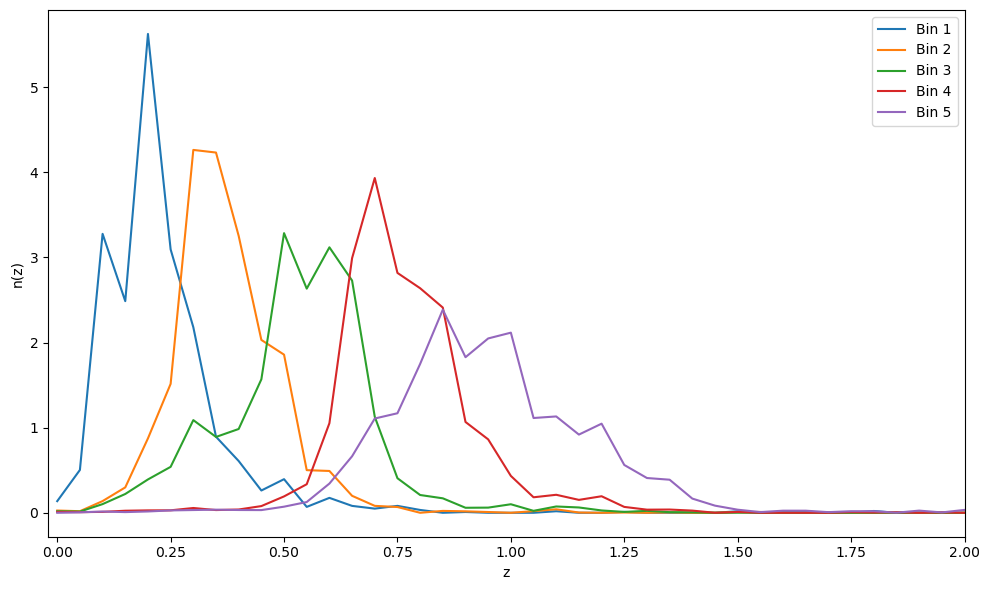

In [9]:
plt.figure(figsize=(10,6))
plt.plot(read1[:,0], read1[:,1]/area1, label=r'Bin 1')
plt.plot(read2[:,0], read2[:,1]/area2, label=r'Bin 2')
plt.plot(read3[:,0], read3[:,1]/area3, label=r'Bin 3')
plt.plot(read4[:,0], read4[:,1]/area4, label=r'Bin 4')
plt.plot(read5[:,0], read5[:,1]/area5, label=r'Bin 5')
plt.xlim(-0.02,2)
plt.xlabel(r"z")
plt.ylabel(r"n(z)")
plt.legend()
plt.tight_layout()
plt.savefig("bins.png")
plt.show()

In [10]:
print("diff1: ", read1[:,0].max() - read1[:,0].min())
print("diff2: ", read2[:,0].max() - read2[:,0].min())
print("diff3: ", read3[:,0].max() - read3[:,0].min())
print("diff4: ", read4[:,0].max() - read4[:,0].min())
print("diff5: ", read5[:,0].max() - read5[:,0].min())

diff1:  5.95
diff2:  5.95
diff3:  5.95
diff4:  5.95
diff5:  5.95


## Area with limits

In [11]:
mask1 = (read1[:,0] > 0.1) & (read1[:,0] <= 0.3)
mask2 = (read2[:,0] > 0.3) & (read2[:,0] <= 0.5)
mask3 = (read3[:,0] > 0.5) & (read3[:,0] <= 0.7)
mask4 = (read4[:,0] > 0.7) & (read4[:,0] <= 0.9)
mask5 = (read5[:,0] > 0.9) & (read5[:,0] <= 1.2)
ar1 = np.trapezoid(read1[:,1][mask1]/area1, read1[:,0][mask1])
ar2 = np.trapezoid(read2[:,1][mask2]/area2, read2[:,0][mask2])
ar3 = np.trapezoid(read3[:,1][mask3]/area3, read3[:,0][mask3])
ar4 = np.trapezoid(read4[:,1][mask4]/area4, read4[:,0][mask4])
ar5 = np.trapezoid(read5[:,1][mask5]/area5, read5[:,0][mask5])


In [12]:
print(ar1, ar2, ar3, ar4, ar5)

0.4207831325701369 0.6287929953531888 0.28997051930231765 0.5183503093204749 0.2922356954685884


In [13]:
print("Bin1 :", round(ar1,3))
print("Bin2 :", round(ar2,3))
print("Bin3 :", round(ar3,3))
print("Bin4 :", round(ar4,3))
print("Bin5 :", round(ar5,3))

Bin1 : 0.421
Bin2 : 0.629
Bin3 : 0.29
Bin4 : 0.518
Bin5 : 0.292


In [14]:
len(tab_pan)

21262011

In [15]:
table2 = Table.read(data[2])

In [16]:
tab_pan1 = table2.to_pandas()

In [17]:
len(tab_pan1)

32456

In [18]:
tab_pan1.columns

Index(['OBJECT_POS', 'OBJECT_COUNT', 'CHANNEL_NR', 'CHANNEL_NAME', 'SubNr'], dtype='object')

In [19]:
tab_pan.columns

Index(['SeqNr', 'SLID', 'SID', 'ID', 'FLUX_AUTO', 'FLUXERR_AUTO', 'MAG_AUTO',
       'MAGERR_AUTO', 'KRON_RADIUS', 'BackGr',
       ...
       'PSF_e2_exp3', 'PSF_e1_exp4', 'PSF_e2_exp4', 'PSF_e1_exp5',
       'PSF_e2_exp5', 'SeqNr_field', 'THELI_INT', 'e1', 'e2', 'weight'],
      dtype='object', length=193)

In [20]:
redshift = tab_pan['Z_B']
b1 = tab_pan[(tab_pan['Z_B'] > 0.1) & (tab_pan['Z_B'] <= 0.3)].copy()
b2 = tab_pan[(tab_pan['Z_B'] > 0.3) & (tab_pan['Z_B'] <= 0.5)].copy()
b3 = tab_pan[(tab_pan['Z_B'] > 0.5) & (tab_pan['Z_B'] <= 0.7)].copy()
b4 = tab_pan[(tab_pan['Z_B'] > 0.7) & (tab_pan['Z_B'] <= 0.9)].copy()
b5 = tab_pan[(tab_pan['Z_B'] > 0.9) & (tab_pan['Z_B'] <= 1.2)].copy()

In [21]:
c1bin1 = np.average(b1['e1'], weights=b1['weight'])
c2bin1 = np.average(b1['e2'], weights=b1['weight'])
corr_e1bin1 = b1['e1']-c1bin1
corr_e2bin1 = b1['e2']-c2bin1
b1['corr_e1'] = corr_e1bin1
b1['corr_e2'] = corr_e2bin1

c1bin2 = np.average(b2['e1'], weights=b2['weight'])
c2bin2 = np.average(b2['e2'], weights=b2['weight'])
corr_e1bin2 = b2['e1']-c1bin2
corr_e2bin2 = b2['e2']-c2bin2
b2['corr_e1'] = corr_e1bin2
b2['corr_e2'] = corr_e2bin2

c1bin3 = np.average(b3['e1'], weights=b3['weight'])
c2bin3 = np.average(b3['e2'], weights=b3['weight'])
corr_e1bin3 = b3['e1']-c1bin3
corr_e2bin3 = b3['e2']-c2bin3
b3['corr_e1'] = corr_e1bin3
b3['corr_e2'] = corr_e2bin3

c1bin4 = np.average(b4['e1'], weights=b4['weight'])
c2bin4 = np.average(b4['e2'], weights=b4['weight'])
corr_e1bin4 = b4['e1']-c1bin4
corr_e2bin4 = b4['e2']-c2bin4
b4['corr_e1'] = corr_e1bin4
b4['corr_e2'] = corr_e2bin4

c1bin5 = np.average(b5['e1'], weights=b5['weight'])
c2bin5 = np.average(b5['e2'], weights=b5['weight'])
corr_e1bin5 = b5['e1']-c1bin5
corr_e2bin5 = b5['e2']-c2bin5
b5['corr_e1'] = corr_e1bin5
b5['corr_e2'] = corr_e2bin5

In [22]:
pc1bin1 = np.average(b1['PSF_e1'], weights=b1['weight'])
pc2bin1 = np.average(b1['PSF_e2'], weights=b1['weight'])
pcorr_e1bin1 = b1['PSF_e1']-pc1bin1
pcorr_e2bin1 = b1['PSF_e2']-pc2bin1
b1['PSF_corr_e1'] = pcorr_e1bin1
b1['PSF_corr_e2'] = pcorr_e2bin1

pc1bin2 = np.average(b2['PSF_e1'], weights=b2['weight'])
pc2bin2 = np.average(b2['PSF_e2'], weights=b2['weight'])
pcorr_e1bin2 = b2['PSF_e1']-pc1bin2
pcorr_e2bin2 = b2['PSF_e2']-pc2bin2
b2['PSF_corr_e1'] = pcorr_e1bin2
b2['PSF_corr_e2'] = pcorr_e2bin2

pc1bin3 = np.average(b3['PSF_e1'], weights=b3['weight'])
pc2bin3 = np.average(b3['PSF_e2'], weights=b3['weight'])
pcorr_e1bin3 = b3['PSF_e1']-pc1bin3
pcorr_e2bin3 = b3['PSF_e2']-pc2bin3
b3['PSF_corr_e1'] = pcorr_e1bin3
b3['PSF_corr_e2'] = pcorr_e2bin3

pc1bin4 = np.average(b4['PSF_e1'], weights=b4['weight'])
pc2bin4 = np.average(b4['PSF_e2'], weights=b4['weight'])
pcorr_e1bin4 = b4['PSF_e1']-pc1bin4
pcorr_e2bin4 = b4['PSF_e2']-pc2bin4
b4['PSF_corr_e1'] = pcorr_e1bin4
b4['PSF_corr_e2'] = pcorr_e2bin4

pc1bin5 = np.average(b5['PSF_e1'], weights=b5['weight'])
pc2bin5 = np.average(b5['PSF_e2'], weights=b5['weight'])
pcorr_e1bin5 = b5['PSF_e1']-pc1bin5
pcorr_e2bin5 = b5['PSF_e2']-pc2bin5
b5['PSF_corr_e1'] = pcorr_e1bin5
b5['PSF_corr_e2'] = pcorr_e2bin5

In [23]:
b4['PSF_corr_e1'].hasnans

False

In [24]:
len(b1), len(b2), len(b3), len(b4), len(b5)

(1792136, 3681319, 6148102, 4544395, 5096059)

In [25]:
len(b1)+ len(b2)+ len(b3)+ len(b4)+ len(b5)

21262011

In [26]:
tab_pan['weight']

0            0.7116
1           15.5395
2           14.4574
3            6.7614
4            9.4653
             ...   
21262006     7.4016
21262007    12.6046
21262008    15.4484
21262009    15.0339
21262010     7.0869
Name: weight, Length: 21262011, dtype: float32

In [27]:
def n_eff(df):
    value = (1/2798640)*((np.sum(df['weight']))**2)/(np.sum((df['weight']**2)))
    return value

In [28]:
neff1 = n_eff(b1)
neff2 = n_eff(b2)
neff3 = n_eff(b3)
neff4 = n_eff(b4)
neff5 = n_eff(b5)

print(neff1, neff2, neff3, neff4, neff5)

0.6163804 1.1821303 1.8541169 1.2592063 1.3108858


In [29]:
import treecorr


b1_tab = Table.from_pandas(b1)
b2_tab = Table.from_pandas(b2)
b3_tab = Table.from_pandas(b3)
b4_tab = Table.from_pandas(b4)
b5_tab = Table.from_pandas(b5)
b1_tab.write("b1.fits", format="fits", overwrite=True)
b2_tab.write("b2.fits", format="fits", overwrite=True)
b3_tab.write("b3.fits", format="fits", overwrite=True)
b4_tab.write("b4.fits", format="fits", overwrite=True)
b5_tab.write("b5.fits", format="fits", overwrite=True)

In [30]:
cat11 = treecorr.Catalog("b1.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')
cat22 = treecorr.Catalog("b2.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')
cat33 = treecorr.Catalog("b3.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')
cat44 = treecorr.Catalog("b4.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')
cat55 = treecorr.Catalog("b5.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')

In [31]:
gg11 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9, 
                            sep_units='arcmin')
gg22 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg33 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg44 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg55 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg12 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg13 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg14 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg15 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg23 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg24 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg25 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg34 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg35 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg45 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')

In [32]:
gg11.process(cat11)
gg22.process(cat22)
gg33.process(cat33)
gg44.process(cat44)
gg55.process(cat55)

gg12.process(cat11, cat22)
gg13.process(cat11, cat33)
gg14.process(cat11, cat44)
gg15.process(cat11, cat55)

gg23.process(cat22, cat33)
gg24.process(cat22, cat44)
gg25.process(cat22, cat55)

gg34.process(cat33, cat44)
gg35.process(cat33, cat55)

gg45.process(cat44, cat55)


In [33]:
m1=-0.009
m2=-0.011
m3=-0.015
m4=0.002
m5=0.007

In [34]:
xip11 = gg11.xip/((1+m1)*(1+m1))
xim11 = gg11.xim  
gg11.write('gg11.out') 

xip22 = gg22.xip/((1+m2)*(1+m2)) 
xim22 = gg22.xim  
# gg22.write('gg22.out')

xip33 = gg33.xip/((1+m3)*(1+m3))
xim33 = gg33.xim 
# gg33.write('gg33.out') 

xip44 = gg44.xip/((1+m4)*(1+m4))
xim44 = gg44.xim 
# gg44.write('gg44.out') 

xip55 = gg55.xip/((1+m5)*(1+m5)) 
xim55 = gg55.xim 

xim12 = gg12.xim 
xim13 = gg13.xim
xim14 = gg14.xim 
xim15 = gg15.xim 

xim23 = gg23.xim 
xim24 = gg24.xim 
xim25 = gg25.xim 

xim34 = gg34.xim 
xim35 = gg35.xim 

xim45 = gg45.xim 

xip12 = gg12.xip/((1+m1)*(1+m2)) 
xip13 = gg13.xip/((1+m1)*(1+m3))
xip14 = gg14.xip/((1+m1)*(1+m4))
xip15 = gg15.xip/((1+m1)*(1+m5))

xip23 = gg23.xip/((1+m2)*(1+m3)) 
xip24 = gg24.xip/((1+m2)*(1+m4))
xip25 = gg25.xip/((1+m2)*(1+m5))

xip34 = gg34.xip/((1+m3)*(1+m4)) 
xip35 = gg35.xip/((1+m3)*(1+m5)) 

xip45 = gg45.xip/((1+m4)*(1+m5)) 

In [35]:
r11 = gg11.meanr
sig11_xip = np.sqrt(gg11.varxip)
sig11_xim = np.sqrt(gg11.varxim)
r22 = gg22.meanr
sig22_xip = np.sqrt(gg22.varxip)
sig22_xim = np.sqrt(gg22.varxim)
r33 = gg33.meanr
sig33_xip = np.sqrt(gg33.varxip)
sig33_xim = np.sqrt(gg33.varxim)
r44 = gg44.meanr
sig44_xip = np.sqrt(gg44.varxip)
sig44_xim = np.sqrt(gg44.varxim)
r55 = gg55.meanr
sig55_xip = np.sqrt(gg55.varxip)
sig55_xim = np.sqrt(gg55.varxim)

r12 = gg12.meanr
sig12_xip = np.sqrt(gg12.varxip)
sig12_xim = np.sqrt(gg12.varxim)
r13 = gg13.meanr
sig13_xip = np.sqrt(gg13.varxip)
sig13_xim = np.sqrt(gg13.varxim)
r14 = gg14.meanr
sig14_xip = np.sqrt(gg14.varxip)
sig14_xim = np.sqrt(gg14.varxim)
r15 = gg15.meanr
sig15_xip = np.sqrt(gg15.varxip)
sig15_xim = np.sqrt(gg15.varxim)

r23 = gg23.meanr
sig23_xip = np.sqrt(gg23.varxip)
sig23_xim = np.sqrt(gg23.varxim)
r24 = gg24.meanr
sig24_xip = np.sqrt(gg24.varxip)
sig24_xim = np.sqrt(gg24.varxim)
r25 = gg25.meanr
sig25_xip = np.sqrt(gg25.varxip)
sig25_xim = np.sqrt(gg25.varxim)

r34 = gg34.meanr
sig34_xip = np.sqrt(gg34.varxip)
sig34_xim = np.sqrt(gg34.varxim)
r35 = gg35.meanr
sig35_xip = np.sqrt(gg35.varxip)
sig35_xim = np.sqrt(gg35.varxim)

r45 = gg45.meanr
sig45_xip = np.sqrt(gg45.varxip)
sig45_xim = np.sqrt(gg45.varxim)

In [36]:
all_r = [r11, r12, r13, r14, r15, r22, r23, r24, r25, r33, r34, r35, r44, r45, r55]
all_xip = [xip11, xip12, xip13, xip14, xip15, xip22, xip23, xip24, xip25, xip33, xip34, xip35, xip44, xip45, xip55]
all_xim = [xim11, xim12, xim13, xim14, xim15, xim22, xim23, xim24, xim25, xim33, xim34, xim35, xim44, xim45, xim55]
all_sig_xip = [sig11_xip, sig12_xip, sig13_xip, sig14_xip, sig15_xip, sig22_xip, sig23_xip, sig24_xip, sig25_xip, sig33_xip, sig34_xip, sig35_xip, sig44_xip, sig45_xip, sig55_xip]
all_sig_xim = [sig11_xim, sig12_xim, sig13_xim, sig14_xim, sig15_xim, sig22_xim, sig23_xim, sig24_xim, sig25_xim, sig33_xim, sig34_xim, sig35_xim, sig44_xim, sig45_xim, sig55_xim]
labels = ['11', '12', '13', '14', '15', '22', '23', '24', '25', '33', '34', '35', '44', '45', '55']

In [37]:
pub = fits.open("/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits")[2]

In [38]:
pub1 = fits.open("/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits")[3]

In [39]:
pub2 = fits.open("/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits")[1]

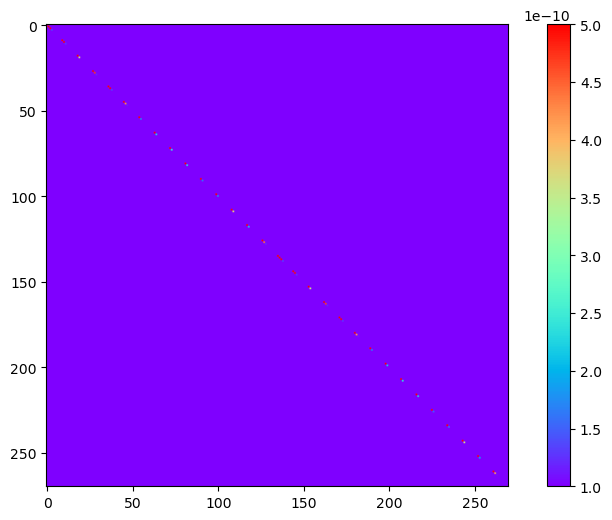

In [40]:
plt.figure(figsize=(10,6))
plt.imshow(pub2.data,cmap="rainbow", vmin=0.1e-9, vmax=0.5e-9)
plt.colorbar()
plt.show()

In [41]:
var = np.diag(pub2.data)
err = np.sqrt(var)
# print(err), len(err)
# print(var)

In [42]:
err_xip_cat = err[0:135] 
err_xim_cat = err[135:270]

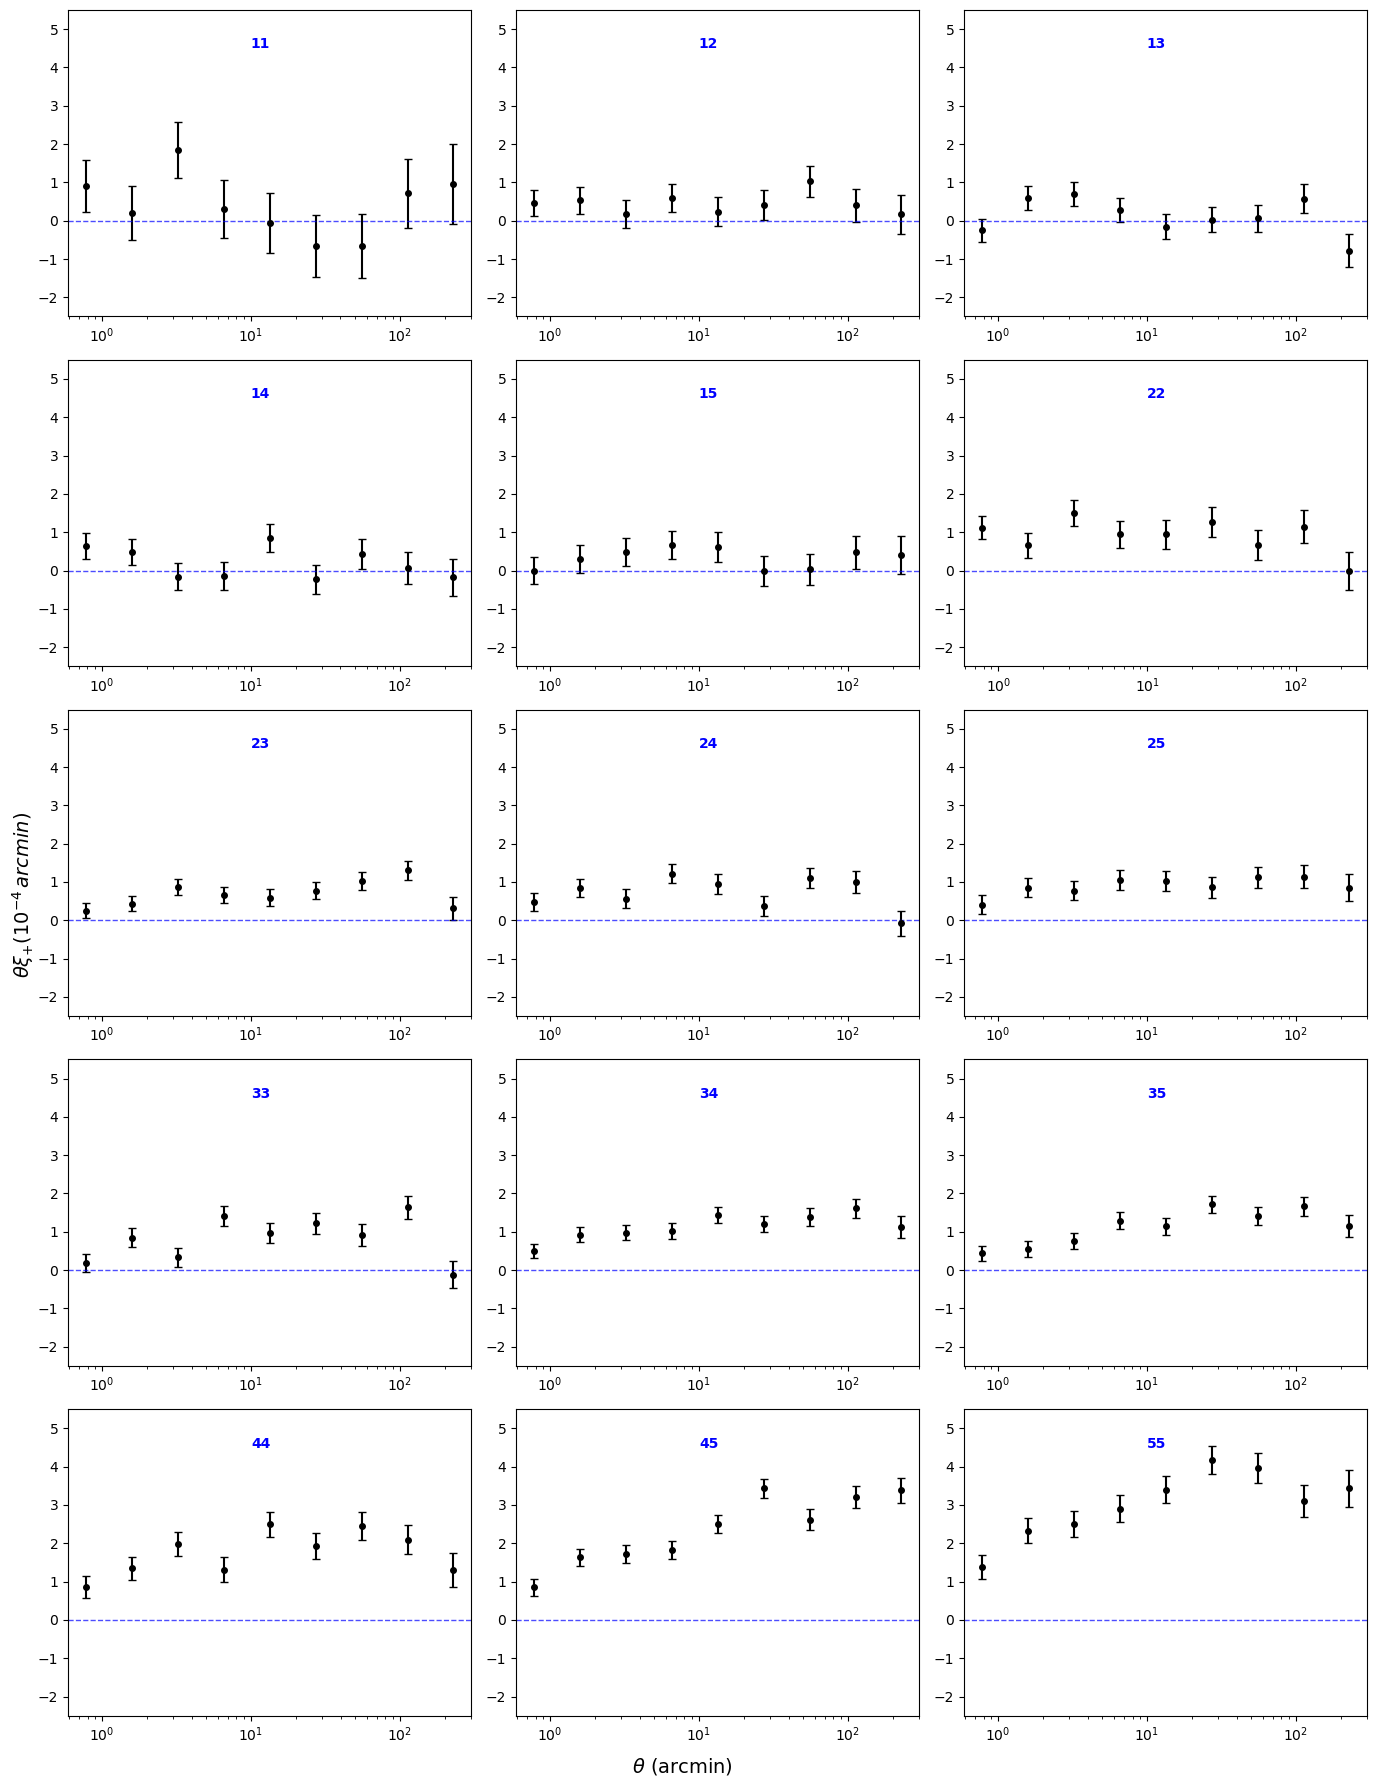

In [43]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18))
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    r = all_r[idx]
    xip = all_xip[idx]
    sig = all_sig_xip[idx]
    
    y = r * xip * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', markersize=4, capsize=3)
    
    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(10,4.5,f'{labels[idx]}', color='blue', fontweight='bold')
    # ax.set_xlabel(r'$\theta$ (arcmin)')
    # ax.set_ylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$')
    ax.set_ylim(-2.5, 5.5)
    ax.set_xscale('log')

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$', fontsize=14)
plt.tight_layout()
plt.savefig("xip1.png")
plt.show()

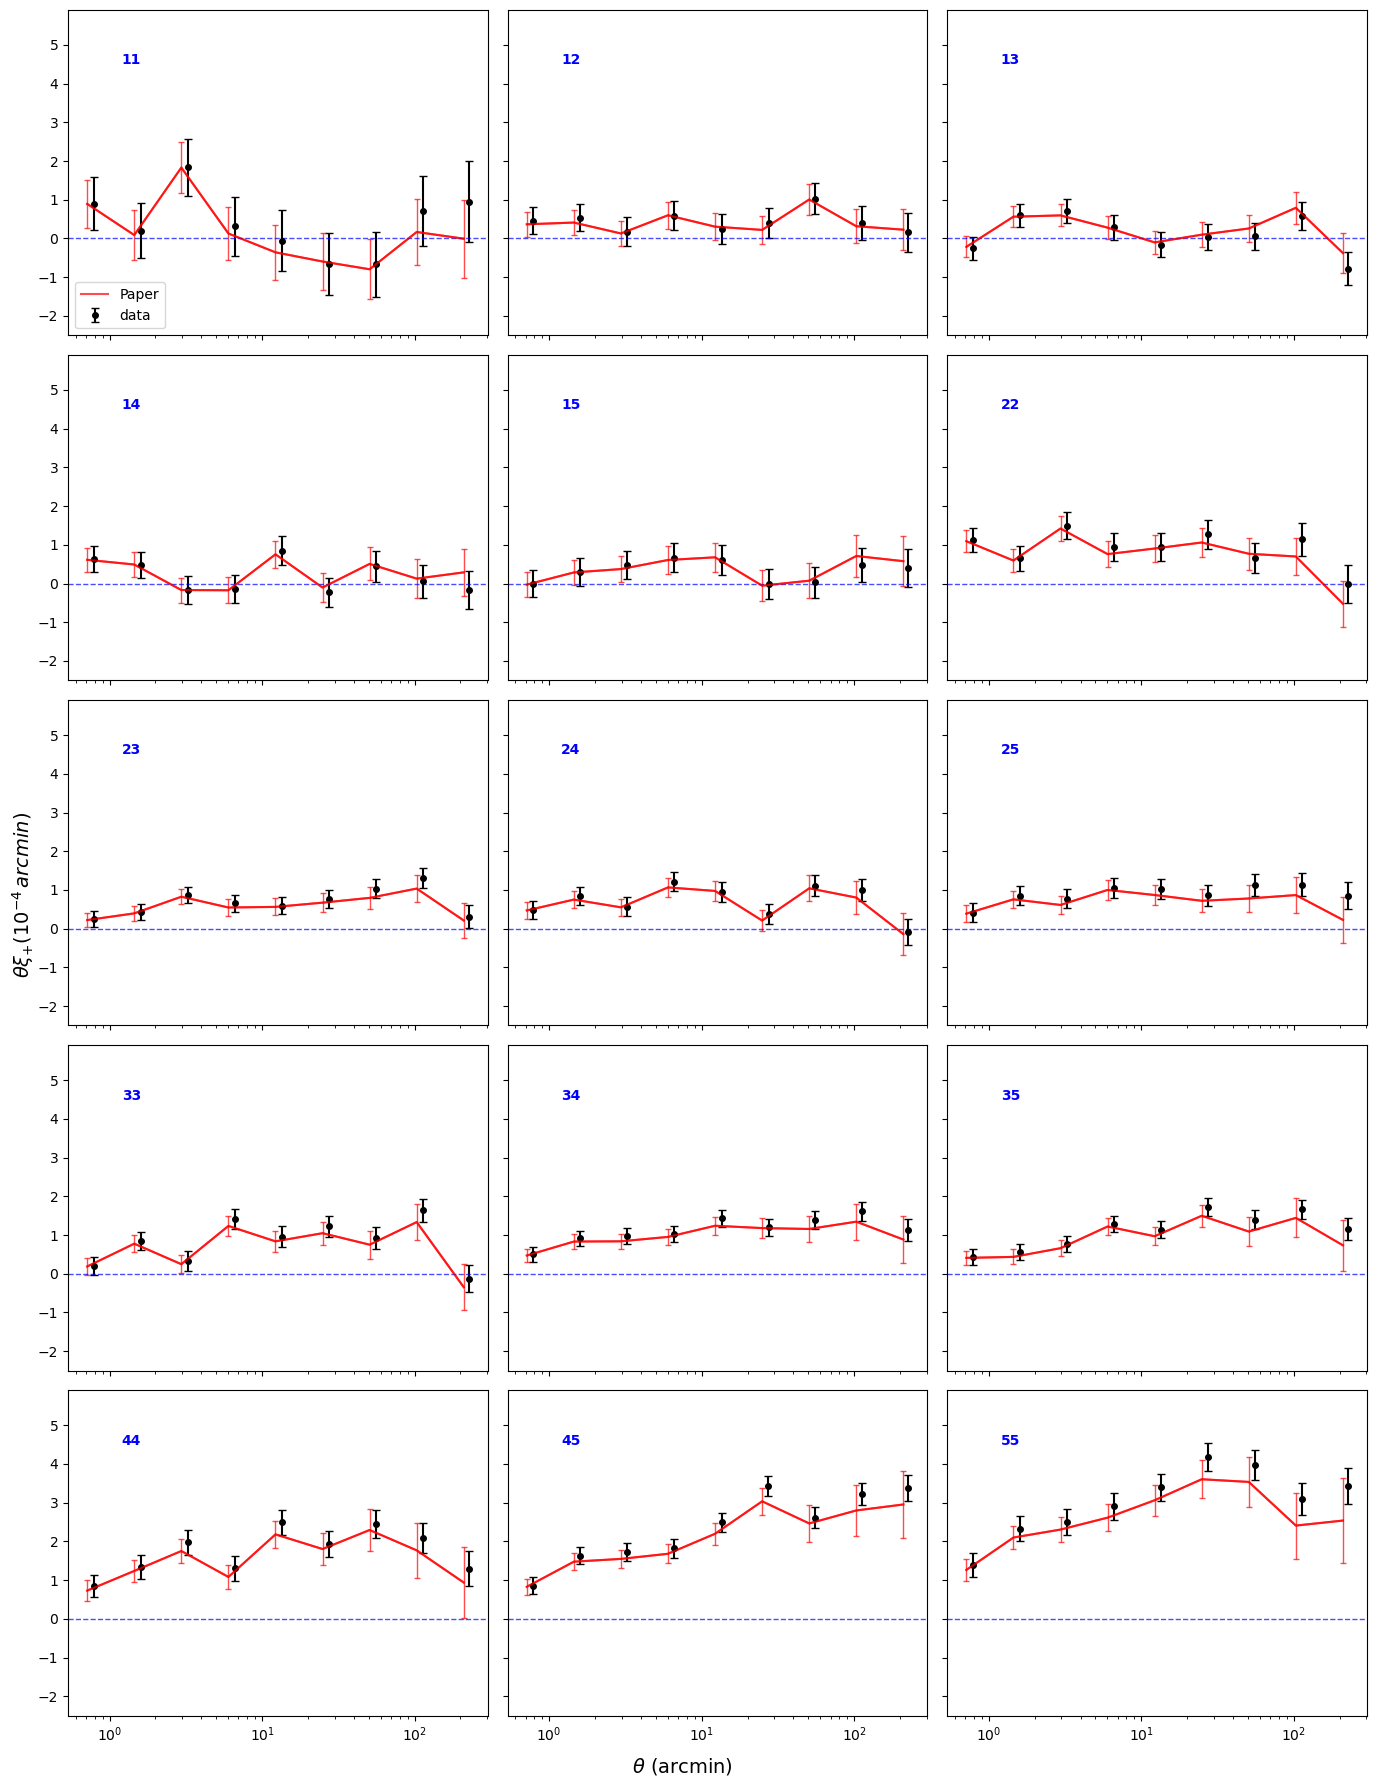

In [44]:
pub_data = pub.data  

pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    
    r = all_r[idx]
    xip = all_xip[idx]
    sig = all_sig_xip[idx]
    
    y = r * xip * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', 
                markersize=4, capsize=3, label='data')
    
    i, j = pairs[idx]
    mask = (pub_data['BIN1'] == i) & (pub_data['BIN2'] == j)
    pair_data = pub_data[mask]
    
    if len(pair_data) > 0:
        cat_theta = pair_data['ANG']
        cat_value = pair_data['VALUE']
        
        cat_y = cat_theta * cat_value * 10**4

        start_slice = idx * 9
        end_slice = (idx + 1) * 9
        cat_raw_err = err_xip_cat[start_slice:end_slice]

        cat_y_err = cat_theta * cat_raw_err * 10**4
        
        ax.plot(cat_theta, cat_y, '-', color='red', alpha=0.7, label='Paper')
        # ax.scatter(cat_theta, cat_y, color='red', s=15, alpha=0.7)
        ax.errorbar(x=cat_theta, y=cat_y, yerr=cat_y_err, fmt='-', color='red', 
                    ecolor='red', elinewidth=1, capsize=2, alpha=0.7)

    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.text(1.2, 4.5, f'{labels[idx]}', color='blue', fontweight='bold', fontsize=10)
    
    ax.set_ylim(-2.5, 5.9)
    ax.set_xscale('log')
    
    if idx == 0:
        ax.legend(loc='lower left', fontsize=10)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$', fontsize=14)

plt.tight_layout()
plt.savefig("xip1_compare.png")
plt.show()


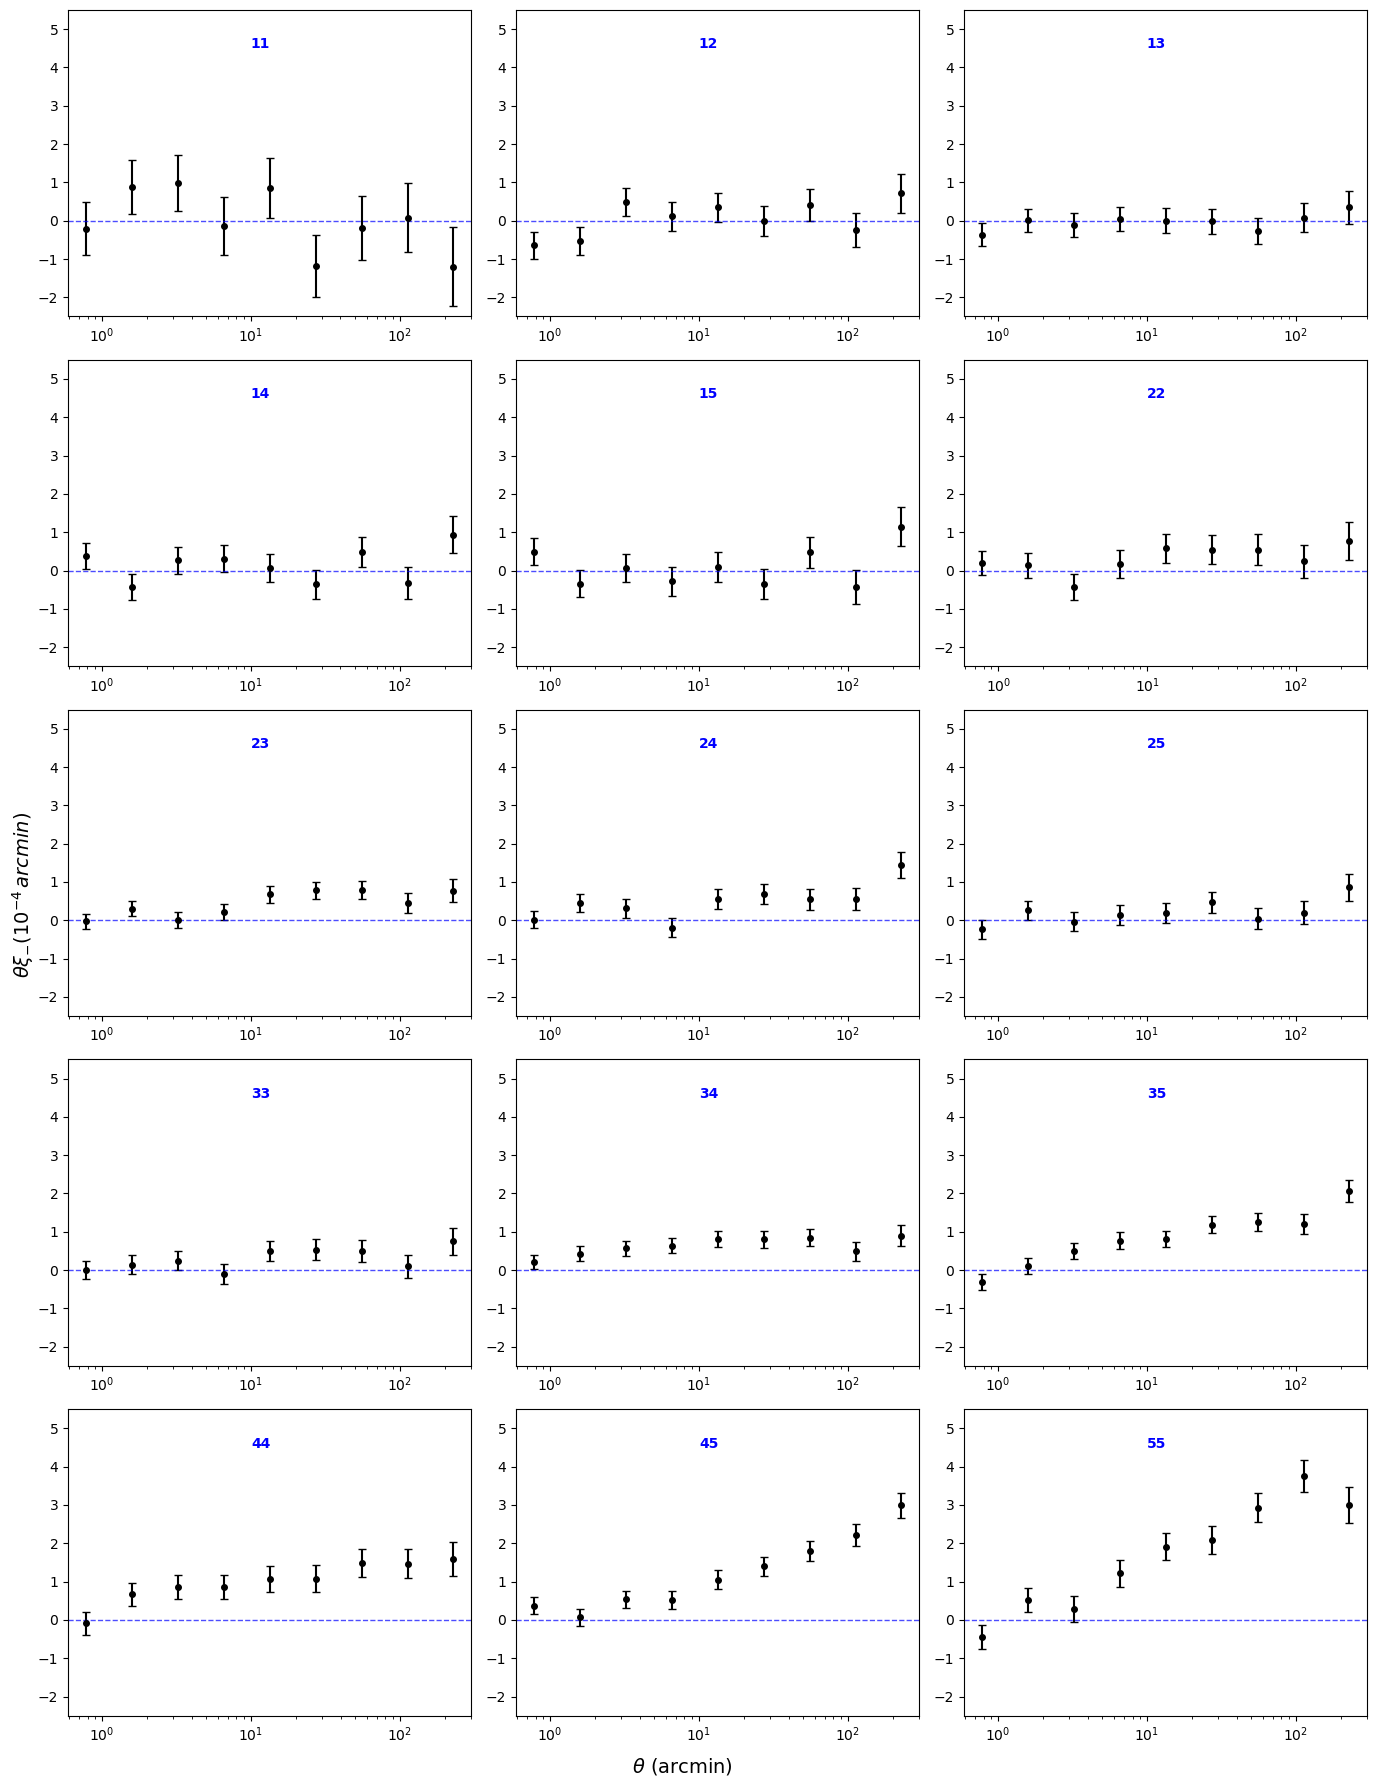

In [45]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18))
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    r = all_r[idx]
    xim = all_xim[idx]
    sig = all_sig_xim[idx]
    
    y = r * xim * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', markersize=4, capsize=3)
    
    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(10,4.5,f'{labels[idx]}', color='blue', fontweight='bold')
    # ax.set_xlabel(r'$\theta$ (arcmin)')
    # ax.set_ylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$')
    ax.set_ylim(-2.5, 5.5)
    ax.set_xscale('log')

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{-} ( 10^{-4} \,arcmin)$', fontsize=14)
plt.tight_layout()
plt.savefig("xim1.png")
plt.show()

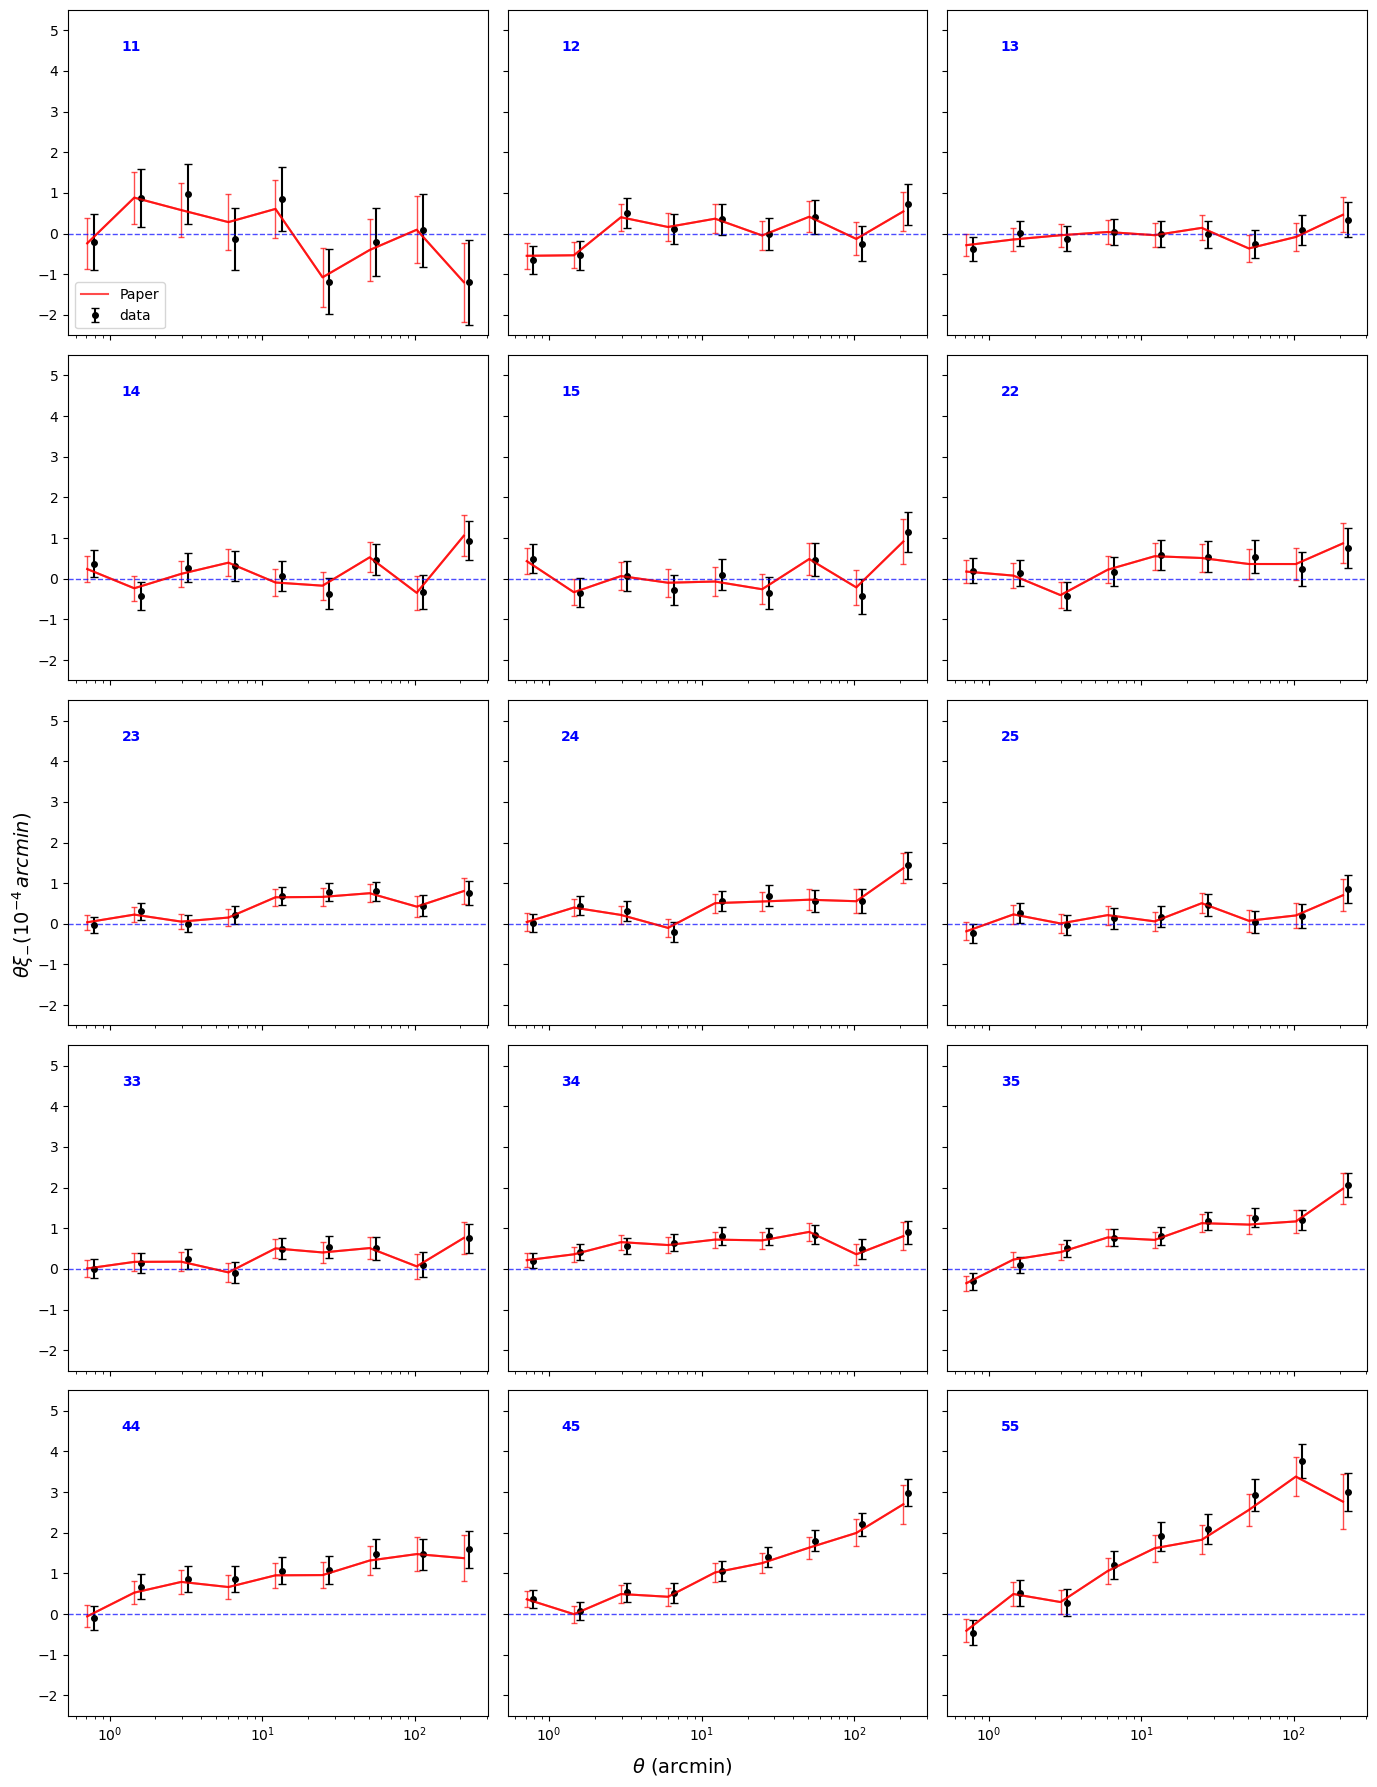

In [46]:
pub1_data = pub1.data  

pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    
    r = all_r[idx]
    xim = all_xim[idx]
    sig = all_sig_xim[idx]
    
    y = r * xim * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', 
                markersize=4, capsize=3, label='data')
    
    i, j = pairs[idx]
    mask = (pub1_data['BIN1'] == i) & (pub1_data['BIN2'] == j)
    pair_data = pub1_data[mask]
    
    if len(pair_data) > 0:
        cat_theta = pair_data['ANG']
        cat_value = pair_data['VALUE']
        
        cat_y = cat_theta * cat_value * 10**4

        start_slice = idx * 9
        end_slice = (idx + 1) * 9
        cat_raw_err = err_xim_cat[start_slice:end_slice]

        cat_y_err = cat_theta * cat_raw_err * 10**4
        
        ax.plot(cat_theta, cat_y, '-', color='red', alpha=0.7, label='Paper')
        # ax.scatter(cat_theta, cat_y, color='red', s=15, alpha=0.7)
        ax.errorbar(x=cat_theta, y=cat_y, yerr=cat_y_err, fmt='-', color='red', 
                    ecolor='red', elinewidth=1, capsize=2, alpha=0.7)

    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.text(1.2, 4.5, f'{labels[idx]}', color='blue', fontweight='bold', fontsize=10)
    
    ax.set_ylim(-2.5, 5.5)
    ax.set_xscale('log')
    
    if idx == 0:
        ax.legend(loc='lower left', fontsize=10)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{-} ( 10^{-4} \,arcmin)$', fontsize=14)

plt.tight_layout()
plt.savefig("xim1_comp.png")
plt.show()


## PSF one

In [47]:
pcat11 = treecorr.Catalog("b1.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='PSF_e1', g2_col='PSF_e2')
pcat22 = treecorr.Catalog("b2.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='PSF_e1', g2_col='PSF_e2')
pcat33 = treecorr.Catalog("b3.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='PSF_e1', g2_col='PSF_e2')
pcat44 = treecorr.Catalog("b4.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='PSF_e1', g2_col='PSF_e2')
pcat55 = treecorr.Catalog("b5.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='PSF_e1', g2_col='PSF_e2')

In [48]:
pgg11 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9, 
                            sep_units='arcmin')
pgg22 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
pgg33 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
pgg44 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
pgg55 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
# pgg12 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg13 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg14 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg15 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg23 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg24 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg25 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg34 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg35 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')
# pgg45 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
#                             sep_units='arcmin')

In [49]:
pgg11.process(pcat11, cat11)
pgg22.process(pcat22, cat22)
pgg33.process(pcat33, cat33)
pgg44.process(pcat44, cat44)
pgg55.process(pcat55, cat55)

# pgg12.process(pcat11, pcat22)
# pgg13.process(pcat11, pcat33)
# pgg14.process(pcat11, pcat44)
# pgg15.process(pcat11, pcat55)

# pgg23.process(pcat22, pcat33)
# pgg24.process(pcat22, pcat44)
# pgg25.process(pcat22, pcat55)

# pgg34.process(pcat33, pcat44)
# pgg35.process(pcat33, pcat55)

# pgg45.process(pcat44, pcat55)


In [50]:
pxip11 = pgg11.xip/((1+m1)*(1+m1))
pxim11 = pgg11.xim  
pgg11.write('pgg11.out') 

pxip22 = pgg22.xip/((1+m2)*(1+m2)) 
pxim22 = pgg22.xim  
# gg22.write('gg22.out')

pxip33 = pgg33.xip/((1+m3)*(1+m3))
pxim33 = pgg33.xim 
# gg33.write('gg33.out') 

pxip44 = pgg44.xip/((1+m4)*(1+m4))
pxim44 = pgg44.xim 
# gg44.write('gg44.out') 

pxip55 = pgg55.xip/((1+m5)*(1+m5)) 
pxim55 = pgg55.xim 

# pxim12 = pgg12.xim 
# pxim13 = pgg13.xim
# pxim14 = pgg14.xim 
# pxim15 = pgg15.xim 

# pxim23 = pgg23.xim 
# pxim24 = pgg24.xim 
# pxim25 = pgg25.xim 

# pxim34 = pgg34.xim 
# pxim35 = pgg35.xim 

# pxim45 = pgg45.xim 

# pxip12 = pgg12.xip/((1+m1)*(1+m2)) 
# pxip13 = pgg13.xip/((1+m1)*(1+m3))
# pxip14 = pgg14.xip/((1+m1)*(1+m4))
# pxip15 = pgg15.xip/((1+m1)*(1+m5))

# pxip23 = pgg23.xip/((1+m2)*(1+m3)) 
# pxip24 = pgg24.xip/((1+m2)*(1+m4))
# pxip25 = pgg25.xip/((1+m2)*(1+m5))

# pxip34 = pgg34.xip/((1+m3)*(1+m4)) 
# pxip35 = pgg35.xip/((1+m3)*(1+m5)) 

# pxip45 = pgg45.xip/((1+m4)*(1+m5)) 

In [51]:
pr11 = pgg11.meanr
psig11_xip = np.sqrt(pgg11.varxip)
psig11_xim = np.sqrt(pgg11.varxim)
pr22 = pgg22.meanr
psig22_xip = np.sqrt(pgg22.varxip)
psig22_xim = np.sqrt(pgg22.varxim)
pr33 = pgg33.meanr
psig33_xip = np.sqrt(pgg33.varxip)
psig33_xim = np.sqrt(pgg33.varxim)
pr44 = pgg44.meanr
psig44_xip = np.sqrt(pgg44.varxip)
psig44_xim = np.sqrt(pgg44.varxim)
pr55 = pgg55.meanr
psig55_xip = np.sqrt(pgg55.varxip)
psig55_xim = np.sqrt(pgg55.varxim)

# pr12 = pgg12.meanr
# psig12_xip = np.sqrt(pgg12.varxip)
# psig12_xim = np.sqrt(pgg12.varxim)
# pr13 = pgg13.meanr
# psig13_xip = np.sqrt(pgg13.varxip)
# psig13_xim = np.sqrt(pgg13.varxim)
# pr14 = pgg14.meanr
# psig14_xip = np.sqrt(pgg14.varxip)
# psig14_xim = np.sqrt(pgg14.varxim)
# pr15 = pgg15.meanr
# psig15_xip = np.sqrt(pgg15.varxip)
# psig15_xim = np.sqrt(pgg15.varxim)

# pr23 = pgg23.meanr
# psig23_xip = np.sqrt(pgg23.varxip)
# psig23_xim = np.sqrt(pgg23.varxim)
# pr24 = pgg24.meanr
# psig24_xip = np.sqrt(pgg24.varxip)
# psig24_xim = np.sqrt(pgg24.varxim)
# pr25 = pgg25.meanr
# psig25_xip = np.sqrt(pgg25.varxip)
# psig25_xim = np.sqrt(pgg25.varxim)

# pr34 = pgg34.meanr
# psig34_xip = np.sqrt(pgg34.varxip)
# psig34_xim = np.sqrt(pgg34.varxim)
# pr35 = pgg35.meanr
# psig35_xip = np.sqrt(pgg35.varxip)
# psig35_xim = np.sqrt(pgg35.varxim)

# pr45 = pgg45.meanr
# psig45_xip = np.sqrt(pgg45.varxip)
# psig45_xim = np.sqrt(pgg45.varxim)

In [52]:
pgg11.varxip

array([1.14822382e-11, 2.96234359e-12, 7.64229408e-13, 1.99268225e-13,
       5.07464415e-14, 1.29551147e-14, 3.41969151e-15, 9.52345462e-16,
       3.17714582e-16])

In [53]:
pall_r = [pr11, pr22, pr33, pr44, pr55]
pall_xip = [pxip11, pxip22, pxip33, pxip44, pxip55]
pall_xim = [pxim11, pxim22, pxim33, pxim44, pxim55]
pall_sig_xip = [psig11_xip, psig22_xip, psig33_xip, psig44_xip, psig55_xip]
pall_sig_xim = [psig11_xim, psig22_xim, psig33_xim, psig44_xim, psig55_xim]
plabels = ['11', '22', '33', '44', '55']

jall_r = [r11, r22, r33, r44, r55]
jall_xip = [xip11, xip22, xip33, xip44, xip55]
jall_xim = [xim11, xim22, xim33, xim44, xim55]
jall_sig_xip = [sig11_xip, sig22_xip, sig33_xip, sig44_xip, sig55_xip]
jall_sig_xim = [sig11_xim, sig22_xim, sig33_xim, sig44_xim, sig55_xim]

# pall_r = [pr11, pr12, pr13, pr14, pr15, pr22, pr23, pr24, pr25, pr33, pr34, pr35, pr44, pr45, pr55]
# pall_xip = [pxip11, pxip12, pxip13, pxip14, pxip15, pxip22, pxip23, pxip24, pxip25, pxip33, pxip34, pxip35, pxip44, pxip45, pxip55]
# pall_xim = [pxim11, pxim12, pxim13, pxim14, pxim15, pxim22, pxim23, pxim24, pxim25, pxim33, pxim34, pxim35, pxim44, pxim45, pxim55]
# pall_sig_xip = [psig11_xip, psig12_xip, psig13_xip, psig14_xip, psig15_xip, psig22_xip, psig23_xip, psig24_xip, psig25_xip, psig33_xip, psig34_xip, psig35_xip, psig44_xip, psig45_xip, psig55_xip]
# pall_sig_xim = [psig11_xim, psig12_xim, psig13_xim, psig14_xim, psig15_xim, psig22_xim, psig23_xim, psig24_xim, psig25_xim, psig33_xim, psig34_xim, psig35_xim, psig44_xim, psig45_xim, psig55_xim]
# labels = ['11', '12', '13', '14', '15', '22', '23', '24', '25', '33', '34', '35', '44', '45', '55']

In [54]:
np.array(pall_xip)*np.array(pall_r)*10**4

array([[ 0.02600989,  0.06333834,  0.11659922,  0.31011228,  0.35374669,
        -0.61444834, -0.98114975, -1.82787706, -4.2225576 ],
       [ 0.07054444,  0.13841083,  0.19604632,  0.25752186, -0.06909323,
        -0.00525885,  0.42392386,  0.80154883, -2.32972202],
       [ 0.0526855 ,  0.11404344,  0.2243151 ,  0.36715145,  0.50253207,
         0.23726423, -0.12572002,  0.44181384,  1.03687368],
       [ 0.16130672,  0.31036797,  0.69006458,  1.08220576,  1.44879967,
         1.3423314 ,  1.35957648,  1.18767289,  1.54236121],
       [-0.07114175, -0.17560372, -0.28524922, -0.47876513, -0.66131267,
        -0.39573183, -0.05796779,  0.30321958, -1.45459065]])

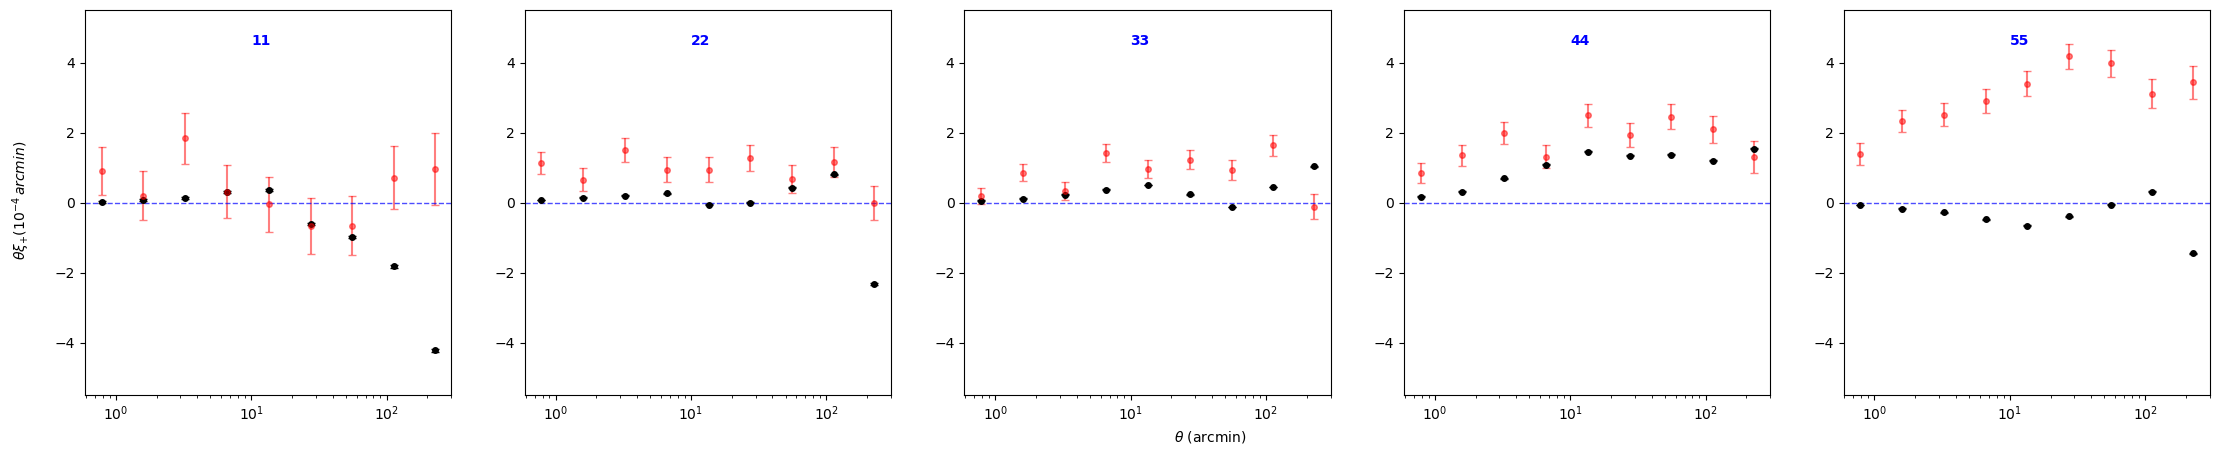

In [55]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(25, 5))
axes = axes.flatten()

for idx in range(5):
    ax = axes[idx]
    r = jall_r[idx]
    xip = jall_xip[idx]
    sig = jall_sig_xip[idx]
    
    y = r * xip * 10**4
    y_err = r * sig * 10**4

    pr = pall_r[idx]
    pxip = pall_xip[idx]
    psig = pall_sig_xip[idx]
    
    py = pr * pxip * 10**4
    py_err = pr * psig * 10**4
    
    ax.errorbar(x=pr, y=py, yerr=py_err, fmt='o', color='black', markersize=4, capsize=3, label="PSF ellip")
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='red', markersize=4, capsize=3, label="Ellp", alpha=0.5)
    
    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(10,4.5,f'{plabels[idx]}', color='blue', fontweight='bold')
    # ax.set_xlabel(r'$\theta$ (arcmin)')
    # ax.set_ylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$')
    ax.set_ylim(-5.5, 5.5)
    ax.set_xscale('log')
    # if idx == 0:
    #     ax.legend(loc='lower left', fontsize=10)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=10)
fig.supylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$', fontsize=10)
plt.subplots_adjust(left=0.05) 
    
# plt.tight_layout()
# plt.savefig("xip1.png")
plt.show()

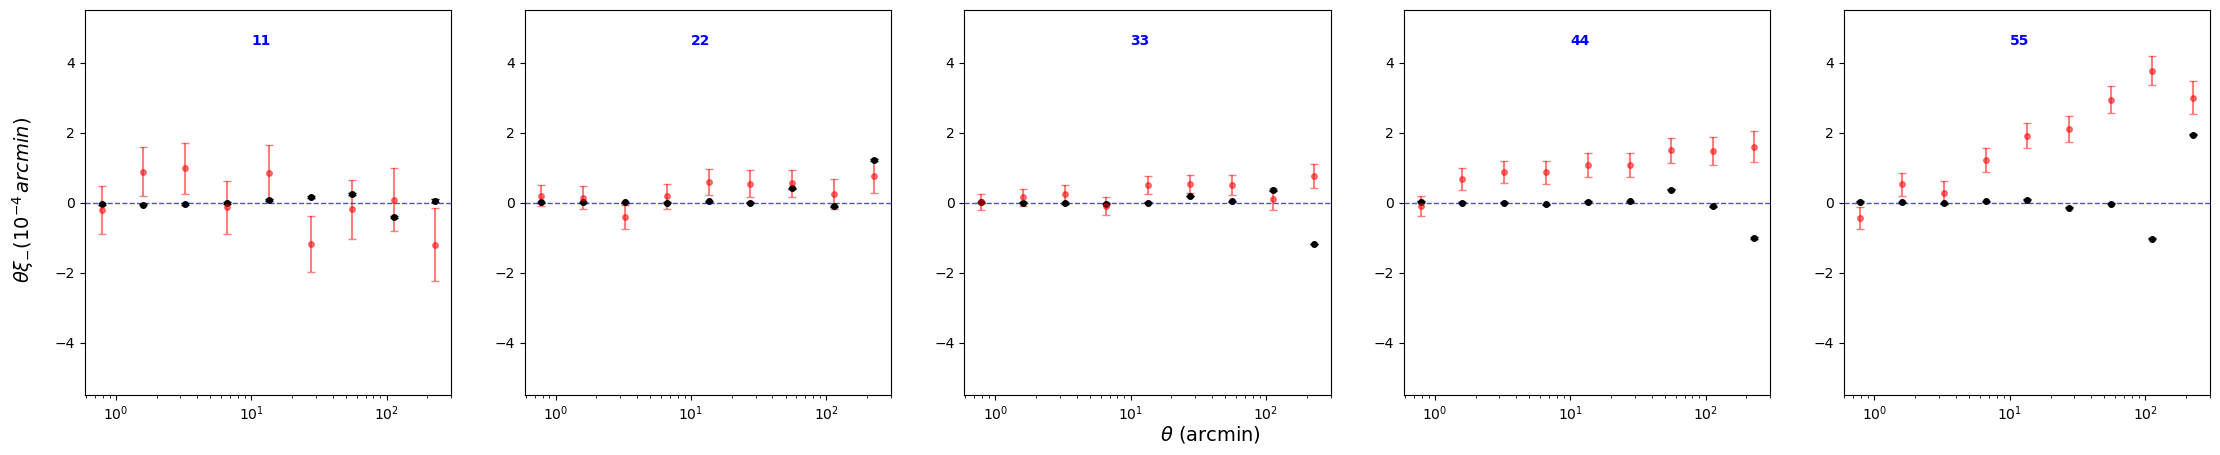

In [56]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(25, 5))
axes = axes.flatten()

for idx in range(5):
    ax = axes[idx]

    r = jall_r[idx]
    xim = jall_xim[idx]
    sig = jall_sig_xim[idx]
    
    y = r * xim * 10**4
    y_err = r * sig * 10**4
    
    pr = pall_r[idx]
    pxim = pall_xim[idx]
    psig = pall_sig_xim[idx]
    
    py = pr * pxim * 10**4
    py_err = pr * psig * 10**4
    
    ax.errorbar(x=pr, y=py, yerr=py_err, fmt='o', color='black', markersize=4, capsize=3, label="PSF ellip")
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='red', markersize=4, capsize=3, label="Ellp", alpha=0.5)
    
    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(10,4.5,f'{plabels[idx]}', color='blue', fontweight='bold')
    # ax.set_xlabel(r'$\theta$ (arcmin)')
    # ax.set_ylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$')
    ax.set_ylim(-5.5, 5.5)
    ax.set_xscale('log')
    # if idx == 0:
    #     ax.legend(loc='lower left', fontsize=10)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{-} ( 10^{-4} \,arcmin)$', fontsize=14)
plt.subplots_adjust(left=0.05) 
    
# plt.tight_layout()
# plt.savefig("xip1.png")
plt.show()

# Exercise 2

In [57]:
phi = np.random.uniform(0, np.pi, size=len(tab_pan['e1']))

e1_rand = tab_pan['e1'] * np.cos(2 * phi) - tab_pan['e2'] * np.sin(2 * phi)
e2_rand = tab_pan['e1'] * np.sin(2 * phi) + tab_pan['e2'] * np.cos(2 * phi)

c1_bias = np.mean(e1_rand)
c2_bias = np.mean(e2_rand)

print(f"additive bias: c1 = {c1_bias:.2e}, c2 = {c2_bias:.2e}")

additive bias: c1 = -1.27e-04, c2 = 4.76e-05


In [58]:
sqrt_orig = np.sqrt(tab_pan['e1']**2 + tab_pan['e2']**2)
sqrt_random = np.sqrt(e1_rand**2 + e2_rand**2)
print(sqrt_orig, sqrt_random)

0           0.481385
1           0.391651
2           0.206244
3           0.259251
4           0.332773
              ...   
21262006    0.138039
21262007    0.098627
21262008    0.479098
21262009    0.330283
21262010    0.156757
Length: 21262011, dtype: float32 0           0.481385
1           0.391651
2           0.206244
3           0.259251
4           0.332773
              ...   
21262006    0.138039
21262007    0.098627
21262008    0.479098
21262009    0.330283
21262010    0.156757
Length: 21262011, dtype: float64


In [59]:
mask1 = (tab_pan['Z_B'] > 0.1) & (tab_pan['Z_B'] <= 0.3)
mask2 = (tab_pan['Z_B'] > 0.3) & (tab_pan['Z_B'] <= 0.5)
mask3 = (tab_pan['Z_B'] > 0.5) & (tab_pan['Z_B'] <= 0.7)
mask4 = (tab_pan['Z_B'] > 0.7) & (tab_pan['Z_B'] <= 0.9)
mask5 = (tab_pan['Z_B'] > 0.9) & (tab_pan['Z_B'] <= 1.2)

In [60]:
c1bin1 = np.average(b1['e1'], weights=b1['weight'])
c2bin1 = np.average(b1['e2'], weights=b1['weight'])

In [61]:
rcat11 = treecorr.Catalog(ra=tab_pan['RAJ2000'][mask1], dec=tab_pan['DECJ2000'][mask1],
                       ra_units='deg', dec_units='deg', w =tab_pan['weight'][mask1],
                       g1=e1_rand[mask1] - np.average(e1_rand[mask1], weights=tab_pan['weight'][mask1]), g2=e2_rand[mask1] - np.average(e2_rand[mask1], weights=tab_pan['weight'][mask1]))
rcat22 = treecorr.Catalog(ra=tab_pan['RAJ2000'][mask2], dec=tab_pan['DECJ2000'][mask2],
                       ra_units='deg', dec_units='deg', w =tab_pan['weight'][mask2],
                       g1=e1_rand[mask2]- np.average(e1_rand[mask2], weights=tab_pan['weight'][mask2]), g2=e2_rand[mask2] - np.average(e2_rand[mask2], weights=tab_pan['weight'][mask2]))
rcat33 = treecorr.Catalog(ra=tab_pan['RAJ2000'][mask3], dec=tab_pan['DECJ2000'][mask3],
                       ra_units='deg', dec_units='deg', w =tab_pan['weight'][mask3],
                       g1=e1_rand[mask3] - np.average(e1_rand[mask3], weights=tab_pan['weight'][mask3]), g2=e2_rand[mask3] - np.average(e2_rand[mask3], weights=tab_pan['weight'][mask3]))
rcat44 = treecorr.Catalog(ra=tab_pan['RAJ2000'][mask4], dec=tab_pan['DECJ2000'][mask4],
                       ra_units='deg', dec_units='deg', w =tab_pan['weight'][mask4],
                       g1=e1_rand[mask4]- np.average(e1_rand[mask4], weights=tab_pan['weight'][mask4]), g2=e2_rand[mask4] - np.average(e2_rand[mask4], weights=tab_pan['weight'][mask4]))
rcat55 = treecorr.Catalog(ra=tab_pan['RAJ2000'][mask5], dec=tab_pan['DECJ2000'][mask5],
                       ra_units='deg', dec_units='deg', w =tab_pan['weight'][mask5],
                       g1=e1_rand[mask5]- np.average(e1_rand[mask5], weights=tab_pan['weight'][mask5]), g2=e2_rand[mask5] - np.average(e2_rand[mask5], weights=tab_pan['weight'][mask5]))

In [62]:
rgg11 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9, 
                            sep_units='arcmin')
rgg22 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg33 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg44 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg55 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg12 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg13 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg14 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg15 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg23 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg24 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg25 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg34 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg35 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
rgg45 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')

In [63]:
rgg11.process(rcat11)
rgg22.process(rcat22)
rgg33.process(rcat33)
rgg44.process(rcat44)
rgg55.process(rcat55)

rgg12.process(rcat11, rcat22)
rgg13.process(rcat11, rcat33)
rgg14.process(rcat11, rcat44)
rgg15.process(rcat11, rcat55)

rgg23.process(rcat22, rcat33)
rgg24.process(rcat22, rcat44)
rgg25.process(rcat22, rcat55)

rgg34.process(rcat33, rcat44)
rgg35.process(rcat33, rcat55)

rgg45.process(rcat44, rcat55)


In [64]:
rxip11 = rgg11.xip/((1+m1)*(1+m1))
rxim11 = rgg11.xim  

rxip22 = rgg22.xip/((1+m2)*(1+m2)) 
rxim22 = rgg22.xim  
# gg22.write('gg22.out')

rxip33 = rgg33.xip/((1+m3)*(1+m3))
rxim33 = rgg33.xim 
# gg33.write('gg33.out') 

rxip44 = rgg44.xip/((1+m4)*(1+m4))
rxim44 = rgg44.xim 
# gg44.write('gg44.out') 

rxip55 = rgg55.xip/((1+m5)*(1+m5)) 
rxim55 = rgg55.xim 

rxim12 = rgg12.xim 
rxim13 = rgg13.xim
rxim14 = rgg14.xim 
rxim15 = rgg15.xim 

rxim23 = rgg23.xim 
rxim24 = rgg24.xim 
rxim25 = rgg25.xim 

rxim34 = rgg34.xim 
rxim35 = rgg35.xim 

rxim45 = rgg45.xim 

rxip12 = rgg12.xip/((1+m1)*(1+m2)) 
rxip13 = rgg13.xip/((1+m1)*(1+m3))
rxip14 = rgg14.xip/((1+m1)*(1+m4))
rxip15 = rgg15.xip/((1+m1)*(1+m5))

rxip23 = rgg23.xip/((1+m2)*(1+m3)) 
rxip24 = rgg24.xip/((1+m2)*(1+m4))
rxip25 = rgg25.xip/((1+m2)*(1+m5))

rxip34 = rgg34.xip/((1+m3)*(1+m4)) 
rxip35 = rgg35.xip/((1+m3)*(1+m5)) 

rxip45 = rgg45.xip/((1+m4)*(1+m5)) 

In [65]:
rr11 = rgg11.meanr
rsig11_xip = np.sqrt(rgg11.varxip)
rsig11_xim = np.sqrt(rgg11.varxim)
rr22 = rgg22.meanr
rsig22_xip = np.sqrt(rgg22.varxip)
rsig22_xim = np.sqrt(rgg22.varxim)
rr33 = rgg33.meanr
rsig33_xip = np.sqrt(rgg33.varxip)
rsig33_xim = np.sqrt(rgg33.varxim)
rr44 = rgg44.meanr
rsig44_xip = np.sqrt(rgg44.varxip)
rsig44_xim = np.sqrt(rgg44.varxim)
rr55 = rgg55.meanr
rsig55_xip = np.sqrt(rgg55.varxip)
rsig55_xim = np.sqrt(rgg55.varxim)

rr12 = rgg12.meanr
rsig12_xip = np.sqrt(rgg12.varxip)
rsig12_xim = np.sqrt(rgg12.varxim)
rr13 = rgg13.meanr
rsig13_xip = np.sqrt(rgg13.varxip)
rsig13_xim = np.sqrt(rgg13.varxim)
rr14 = rgg14.meanr
rsig14_xip = np.sqrt(rgg14.varxip)
rsig14_xim = np.sqrt(rgg14.varxim)
rr15 = rgg15.meanr
rsig15_xip = np.sqrt(rgg15.varxip)
rsig15_xim = np.sqrt(rgg15.varxim)

rr23 = rgg23.meanr
rsig23_xip = np.sqrt(rgg23.varxip)
rsig23_xim = np.sqrt(rgg23.varxim)
rr24 = rgg24.meanr
rsig24_xip = np.sqrt(rgg24.varxip)
rsig24_xim = np.sqrt(rgg24.varxim)
rr25 = rgg25.meanr
rsig25_xip = np.sqrt(rgg25.varxip)
rsig25_xim = np.sqrt(rgg25.varxim)

rr34 = rgg34.meanr
rsig34_xip = np.sqrt(rgg34.varxip)
rsig34_xim = np.sqrt(rgg34.varxim)
rr35 = rgg35.meanr
rsig35_xip = np.sqrt(rgg35.varxip)
rsig35_xim = np.sqrt(rgg35.varxim)

rr45 = rgg45.meanr
rsig45_xip = np.sqrt(rgg45.varxip)
rsig45_xim = np.sqrt(rgg45.varxim)

In [66]:
rall_r = [rr11, rr12, rr13, rr14, rr15, rr22, rr23, rr24, rr25, rr33, rr34, rr35, rr44, rr45, rr55]
rall_xip = [rxip11, rxip12, rxip13, rxip14, rxip15, rxip22, rxip23, rxip24, rxip25, rxip33, rxip34, rxip35, rxip44, rxip45, rxip55]
rall_xim = [rxim11, rxim12, rxim13, rxim14, rxim15, rxim22, rxim23, rxim24, rxim25, rxim33, rxim34, rxim35, rxim44, rxim45, rxim55]
rall_sig_xip = [rsig11_xip, rsig12_xip, rsig13_xip, rsig14_xip, rsig15_xip, rsig22_xip, rsig23_xip, rsig24_xip, rsig25_xip, rsig33_xip, rsig34_xip, rsig35_xip, rsig44_xip, rsig45_xip, rsig55_xip]
rall_sig_xim = [rsig11_xim, rsig12_xim, rsig13_xim, rsig14_xim, rsig15_xim, rsig22_xim, rsig23_xim, rsig24_xim, rsig25_xim, rsig33_xim, rsig34_xim, rsig35_xim, rsig44_xim, rsig45_xim, rsig55_xim]
labels = ['11', '12', '13', '14', '15', '22', '23', '24', '25', '33', '34', '35', '44', '45', '55']

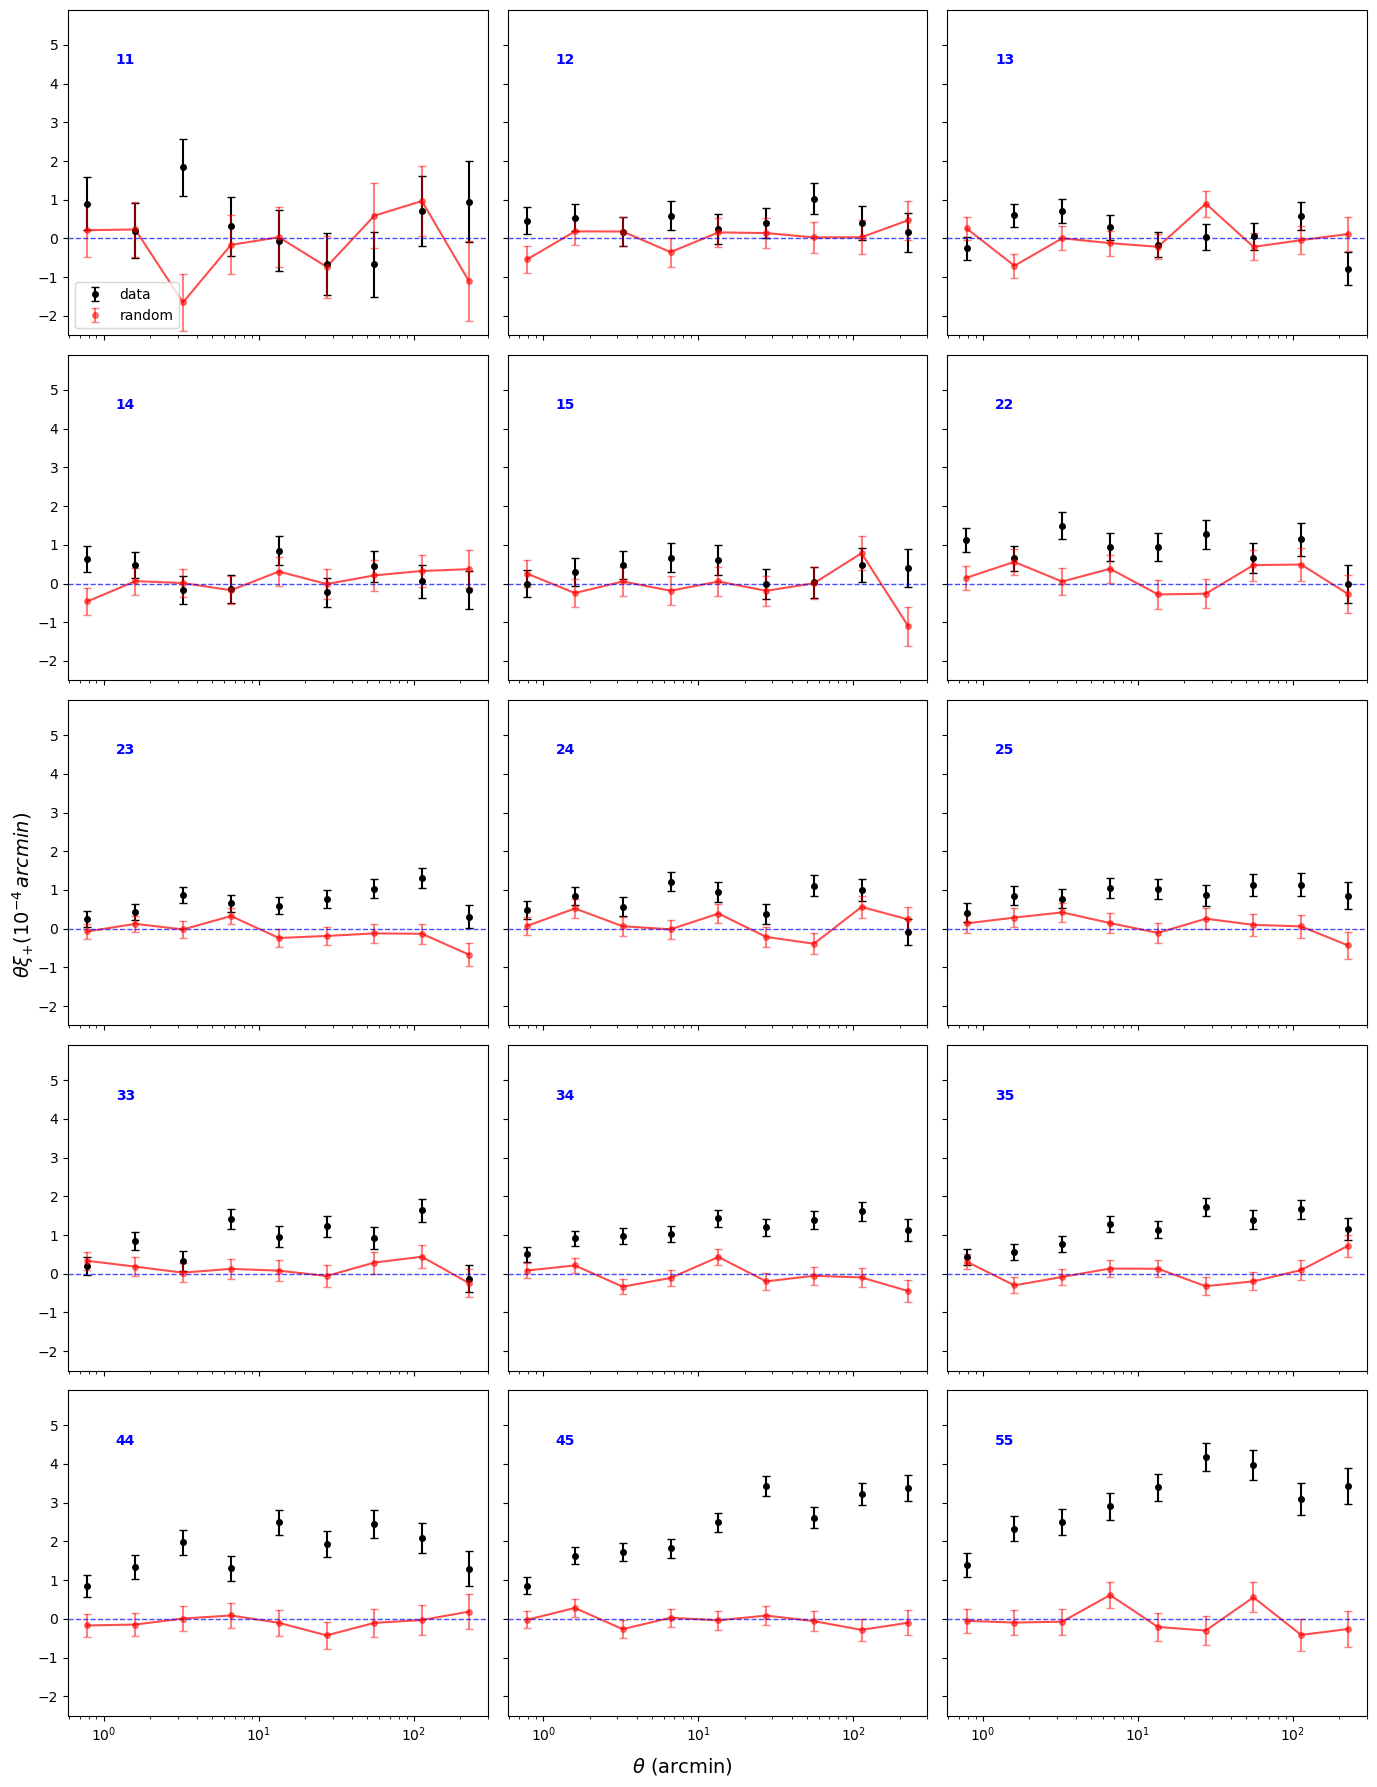

In [67]:
pub_data = pub.data  

pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    
    r = all_r[idx]
    xip = all_xip[idx]
    sig = all_sig_xip[idx]
    
    y = r * xip * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', 
                markersize=4, capsize=3, label='data')

    rr = rall_r[idx]
    rxip = rall_xip[idx]
    rsig = rall_sig_xip[idx]
    
    ry = rr * rxip * 10**4
    ry_err = rr * rsig * 10**4
    
    ax.errorbar(x=rr, y=ry, yerr=ry_err, fmt='o', color='red', 
                markersize=4, capsize=3, label='random', alpha=0.5)
    ax.plot(rr, ry, color='red', alpha=0.7)
    

    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.text(1.2, 4.5, f'{labels[idx]}', color='blue', fontweight='bold', fontsize=10)
    
    ax.set_ylim(-2.5, 5.9)
    ax.set_xscale('log')
    
    if idx == 0:
        ax.legend(loc='lower left', fontsize=10)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$', fontsize=14)

plt.tight_layout()
plt.savefig("xip1_compare_random.png")
plt.show()


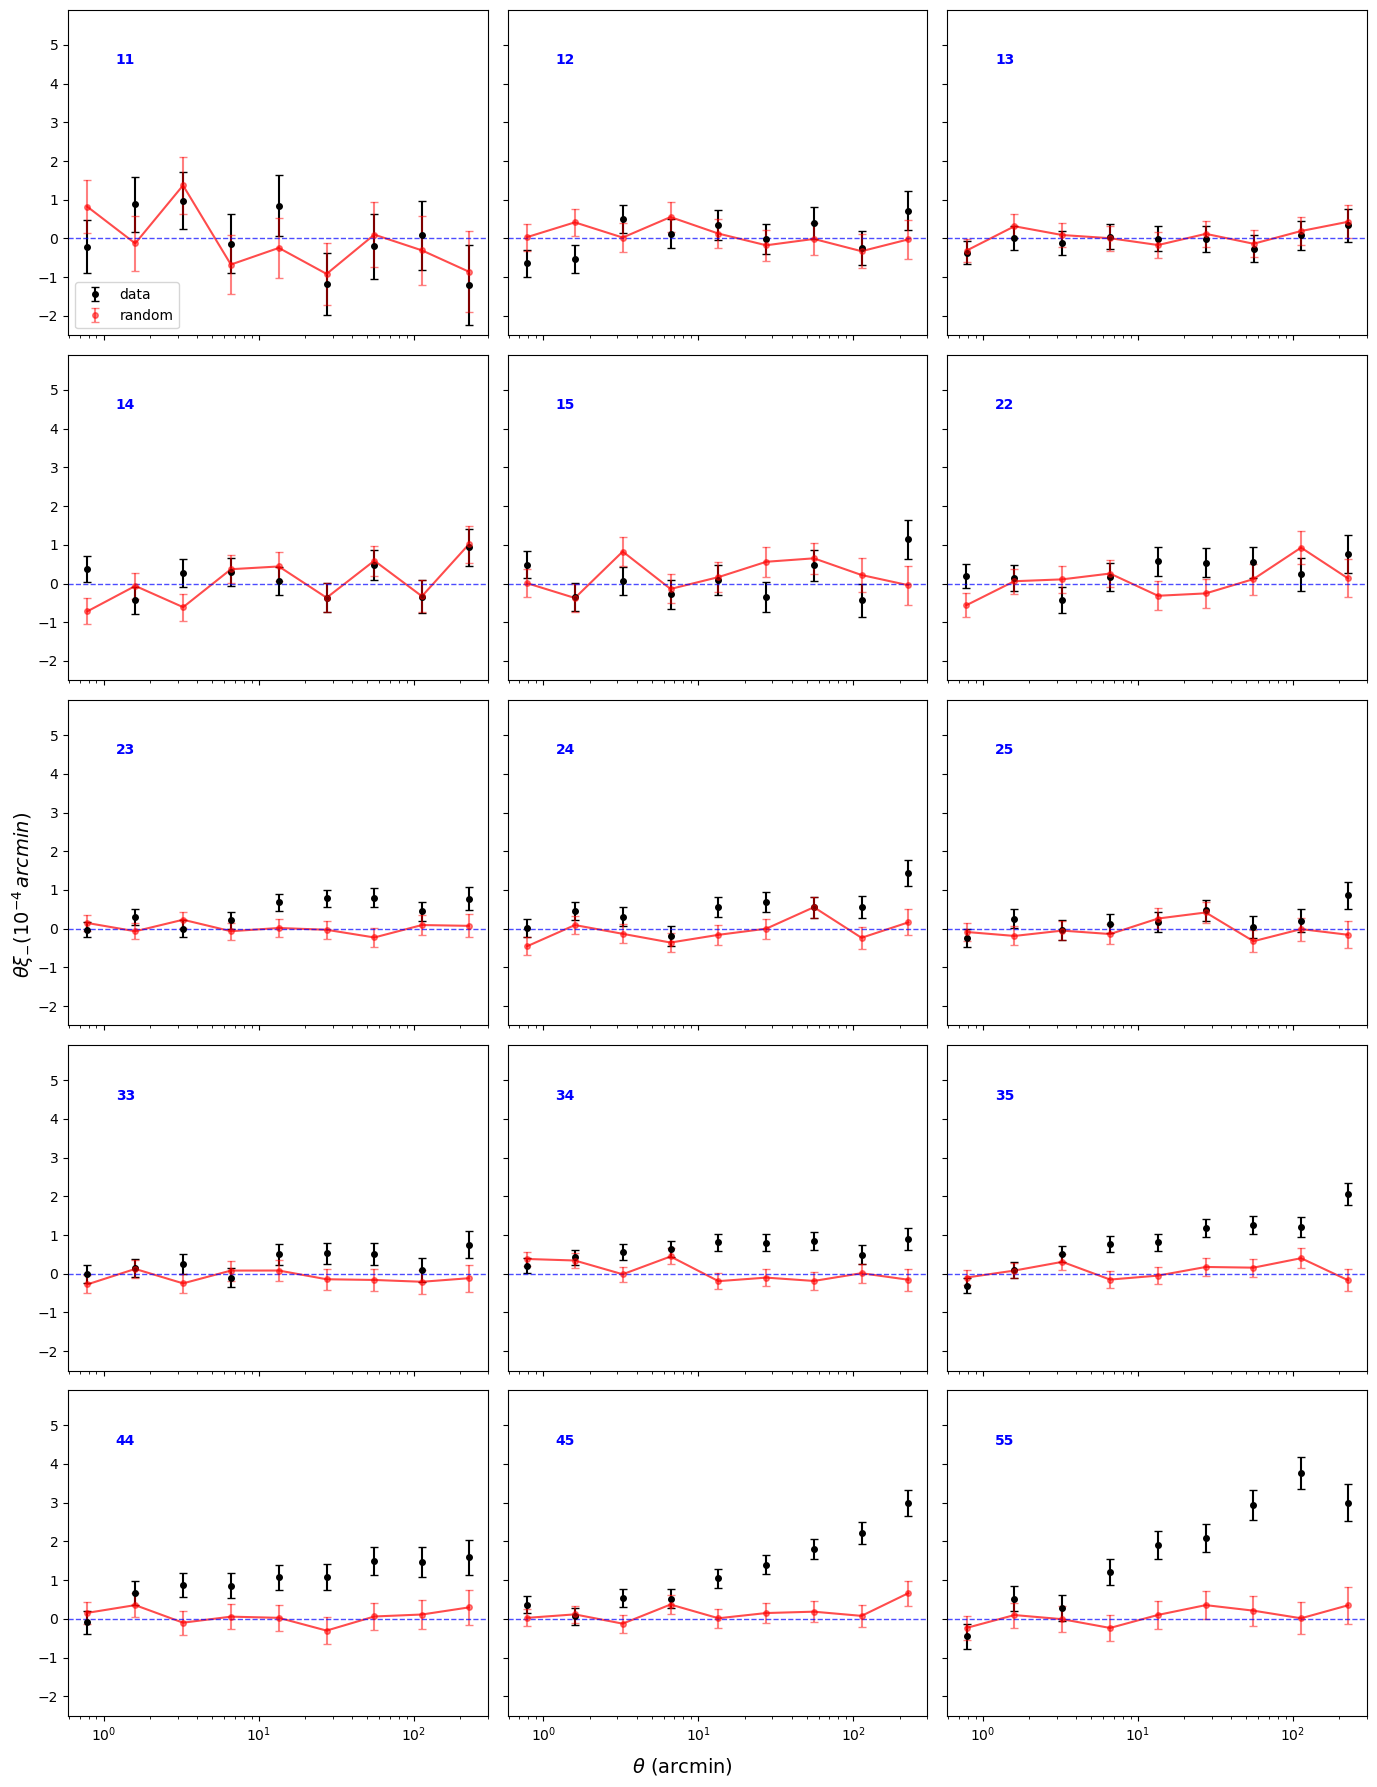

In [68]:
pub_data = pub.data  

pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    
    r = all_r[idx]
    xim = all_xim[idx]
    sig = all_sig_xim[idx]
    
    y = r * xim * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', 
                markersize=4, capsize=3, label='data')

    rr = rall_r[idx]
    rxim = rall_xim[idx]
    rsig = rall_sig_xim[idx]
    
    ry = rr * rxim * 10**4
    ry_err = rr * rsig * 10**4
    
    ax.errorbar(x=rr, y=ry, yerr=ry_err, fmt='o', color='red', 
                markersize=4, capsize=3, label='random', alpha=0.5)
    ax.plot(rr, ry, color='red', alpha=0.7)
    

    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.text(1.2, 4.5, f'{labels[idx]}', color='blue', fontweight='bold', fontsize=10)
    
    ax.set_ylim(-2.5, 5.9)
    ax.set_xscale('log')
    
    if idx == 0:
        ax.legend(loc='lower left', fontsize=10)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{-} ( 10^{-4} \,arcmin)$', fontsize=14)

plt.tight_layout()
plt.savefig("xim1_compare_random.png")
plt.show()
